

# 🧠 **Brain Tumor Detection (EfficientNet + TensorFlow)**

# Test Accuracy: 94.63%

An AI-powered medical imaging system that detects brain tumors from MRI scans using a deep learning model based on the EfficientNet architecture.

This project builds a Deep Learning model for classifying brain MRI images into different tumor categories to assist in early diagnosis and medical decision-making.

The model analyzes MRI scans and classifies them into:

- 🧠 Glioma Tumor
- 🧠 Meningioma Tumor
- 🧠 Pituitary Tumor
- ✅ No Tumor

Using EfficientNet, the model benefits from a highly optimized convolutional neural network architecture that achieves strong performance while maintaining computational efficiency.

# 📦 **Import Libraries**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
import os

from tqdm import tqdm
import itertools


from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , classification_report 
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, AveragePooling2D, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

np.random.seed(42)

2026-03-08 11:18:16.519739: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772968696.692365      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772968696.744595      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772968697.169668      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772968697.169714      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772968697.169716      24 computation_placer.cc:177] computation placer alr

# 🗂️ Data Preparation

In [2]:
def make_dataset(path):
    data_path = path

    all_paths = []
    all_labels = []

    
    all_folders = os.listdir(data_path)

    for folder in all_folders:
        
        folder_path = os.path.join(data_path , folder)
                    
        all_imgs = os.listdir(folder_path)
        
        for img in all_imgs:
            image_path = os.path.join(folder_path,img)
            
            all_paths.append(image_path)
            
            all_labels.append(folder)
            
            
    paths = pd.Series(all_paths, name = "img_path")
    labels = pd.Series(all_labels, name = "img_label")

    return pd.concat([paths, labels], axis=1)

In [3]:
training_data = make_dataset(r'/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training')
training_data

,img_path,img_label
0,/kaggle/input/datasets/masoudnickparvar/brain-...,pituitary
1,/kaggle/input/datasets/masoudnickparvar/brain-...,pituitary
2,/kaggle/input/datasets/masoudnickparvar/brain-...,pituitary
3,/kaggle/input/datasets/masoudnickparvar/brain-...,pituitary
4,/kaggle/input/datasets/masoudnickparvar/brain-...,pituitary
...,...,...
5595,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma
5596,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma
5597,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma
5598,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma


In [4]:
testing_data = make_dataset(r'/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing')
testing_data

,img_path,img_label
0,/kaggle/input/datasets/masoudnickparvar/brain-...,pituitary
1,/kaggle/input/datasets/masoudnickparvar/brain-...,pituitary
2,/kaggle/input/datasets/masoudnickparvar/brain-...,pituitary
3,/kaggle/input/datasets/masoudnickparvar/brain-...,pituitary
4,/kaggle/input/datasets/masoudnickparvar/brain-...,pituitary
...,...,...
1595,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma
1596,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma
1597,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma
1598,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma


In [5]:
valid_df, test_df = train_test_split(testing_data, train_size=0.5, shuffle= True, random_state=42)

# ⚙️ Data Pipeline

In [6]:
from tensorflow.keras.applications.efficientnet import preprocess_input

batch_size = 30
img_size = (256, 256)

tr_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

ts_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = tr_gen.flow_from_dataframe(
    training_data, 
    x_col='img_path',  
    y_col='img_label', 
    target_size=img_size, 
    class_mode='categorical',
    color_mode='rgb', 
    shuffle=True, 
    batch_size=batch_size
)

valid_generator = ts_gen.flow_from_dataframe(
    valid_df, 
    x_col='img_path',
    y_col='img_label', 
    target_size=img_size, 
    class_mode='categorical',
    color_mode='rgb', 
    shuffle=False, 
    batch_size=batch_size
)

test_generator = ts_gen.flow_from_dataframe(
    test_df, 
    x_col='img_path',
    y_col='img_label', 
    target_size=img_size, 
    class_mode='categorical',
    color_mode='rgb', 
    shuffle=False, 
    batch_size=batch_size
)

Found 5600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.


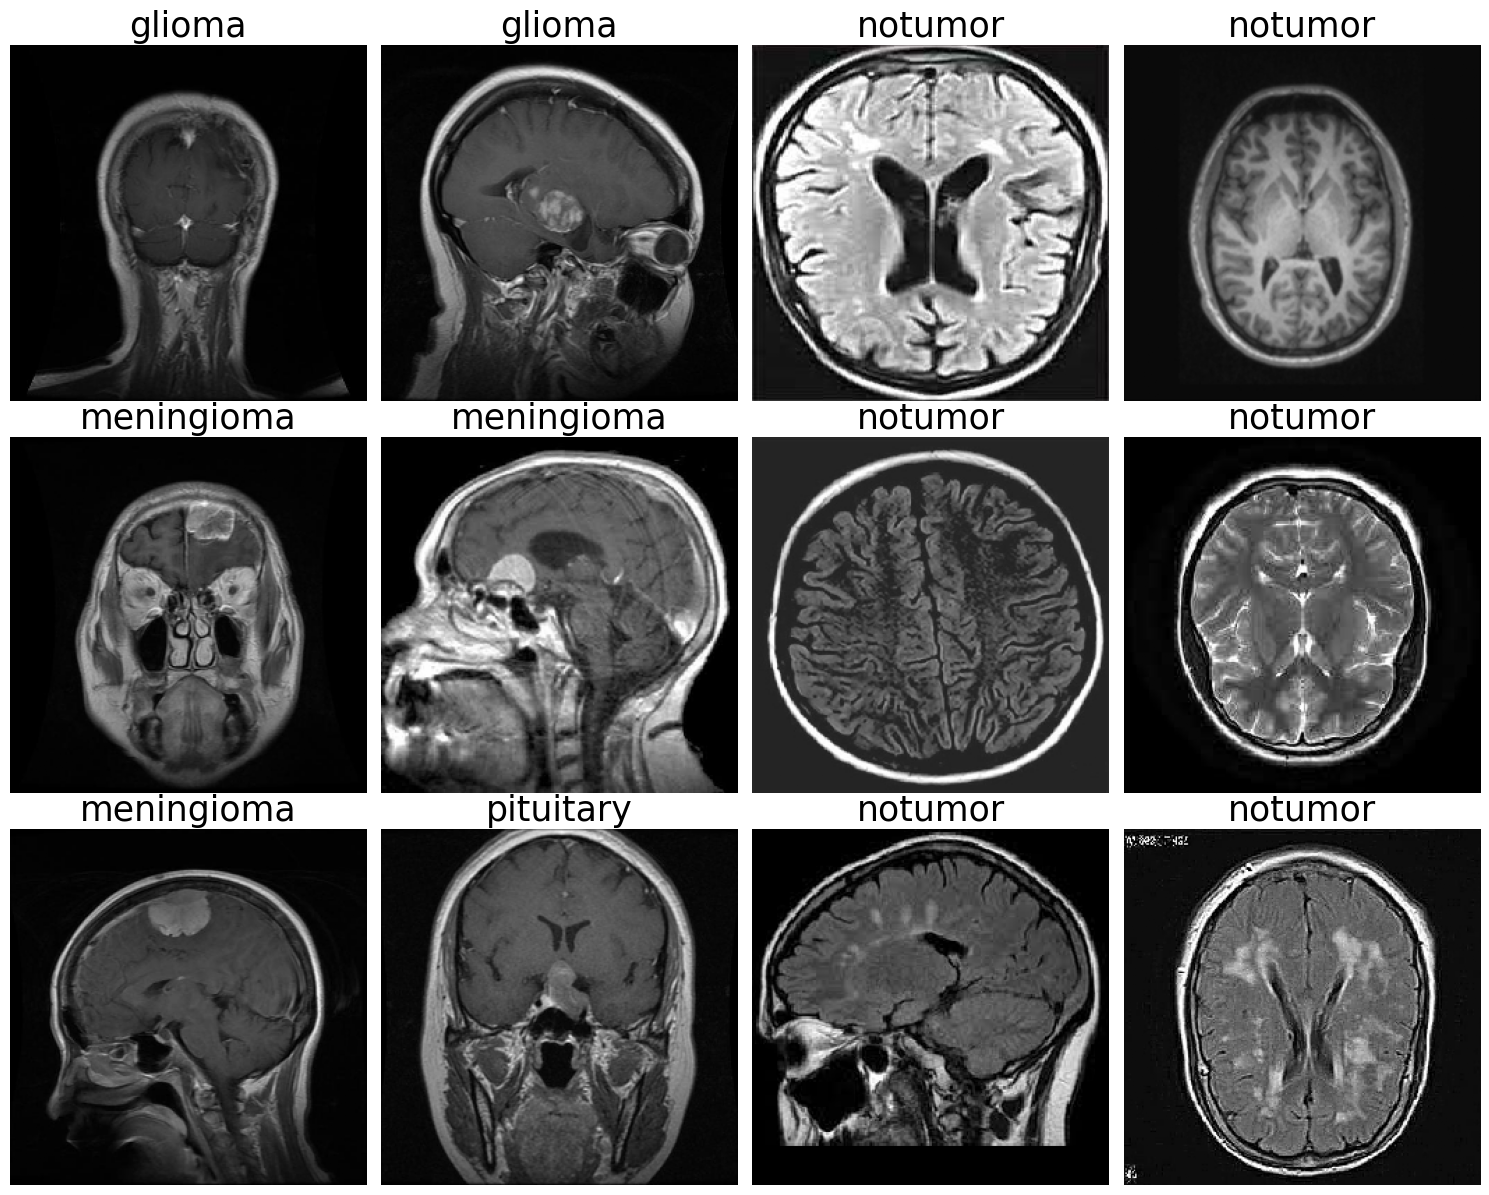

In [7]:
gen_dict = train_generator.class_indices
classes = list(gen_dict.keys())

images, labels = next(train_generator)

plt.figure(figsize=(15, 12))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    
    image = images[i] / 255.0
    
    # Display the image
    plt.imshow(image , cmap='gray')
    
    index = np.argmax(labels[i])  
    class_name = classes[index]   
    
    plt.title(class_name, color='black', fontsize=25)
    plt.axis('off')

plt.tight_layout()
plt.show()

# 🏗️ Model Architecture

In [8]:
img_shape = (img_size[0], img_size[1] ,3)
class_count = len(list(train_generator.class_indices.keys())) 

strategy = tf.distribute.MirroredStrategy()  

with strategy.scope():
    base_model = keras.applications.EfficientNetB4(
        include_top=False,
        weights="imagenet",
        input_shape=(256, 256, 3),
        pooling='max',
    )
    base_model.trainable = False
    
    model = Sequential([
        base_model,
        BatchNormalization(),
        Dense(256, activation="relu"),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.2),
        Dense(4, activation="softmax")
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

model.summary()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)


I0000 00:00:1772968767.112985      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb4 (Functional)     │ (None, 1792)           │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1792)           │         7,168 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       459,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,174,947 (69.33 MB)

 Trainable params: 496,772 (1.90 MB)

 Non-trainable params: 17,678,175 (67.44 MB)

# 🏋️ Training

In [9]:
print("🔓 Phase : Transfer Learning with freeze weights")

early_stopping = EarlyStopping(
    monitor='val_loss',      
    patience=8,             
    restore_best_weights=True,  
    verbose=1
)


reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,        
    patience=3,        
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    train_generator,
    epochs=40,
    verbose=1,
    validation_data=valid_generator,
    shuffle=False,
    callbacks=[early_stopping]
)

🔓 Phase : Transfer Learning with freeze weights


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
Epoch 1/40


E0000 00:00:1772968789.054052      24 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1/efficientnetb4_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1772968791.574937      67 cuda_dnn.cc:529] Loaded cuDNN version 91002


187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.7506 - loss: 0.6939INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
187/187 ━━━━━━━━━━━━━━━━━━━━ 106s 501ms/step - accuracy: 0.7510 - loss: 0.6930 - val_accuracy: 0.8525 - val_loss: 0.4890
Epoch 2/40
187/187 ━━━━━━━━━━━━━━━━━━━━ 29s 157ms/step - accuracy: 0.8879 - loss: 0.3011 - val_accuracy: 0.8900 - val_loss: 0.4131
Epoch 3/40
187/187 ━━━━━━━━━━━━━━━━━━━━ 29s 156ms/step - accuracy: 0.9143 - loss: 0.2317 - val_accuracy: 0.9013 

# 📈 Results & Evaluation

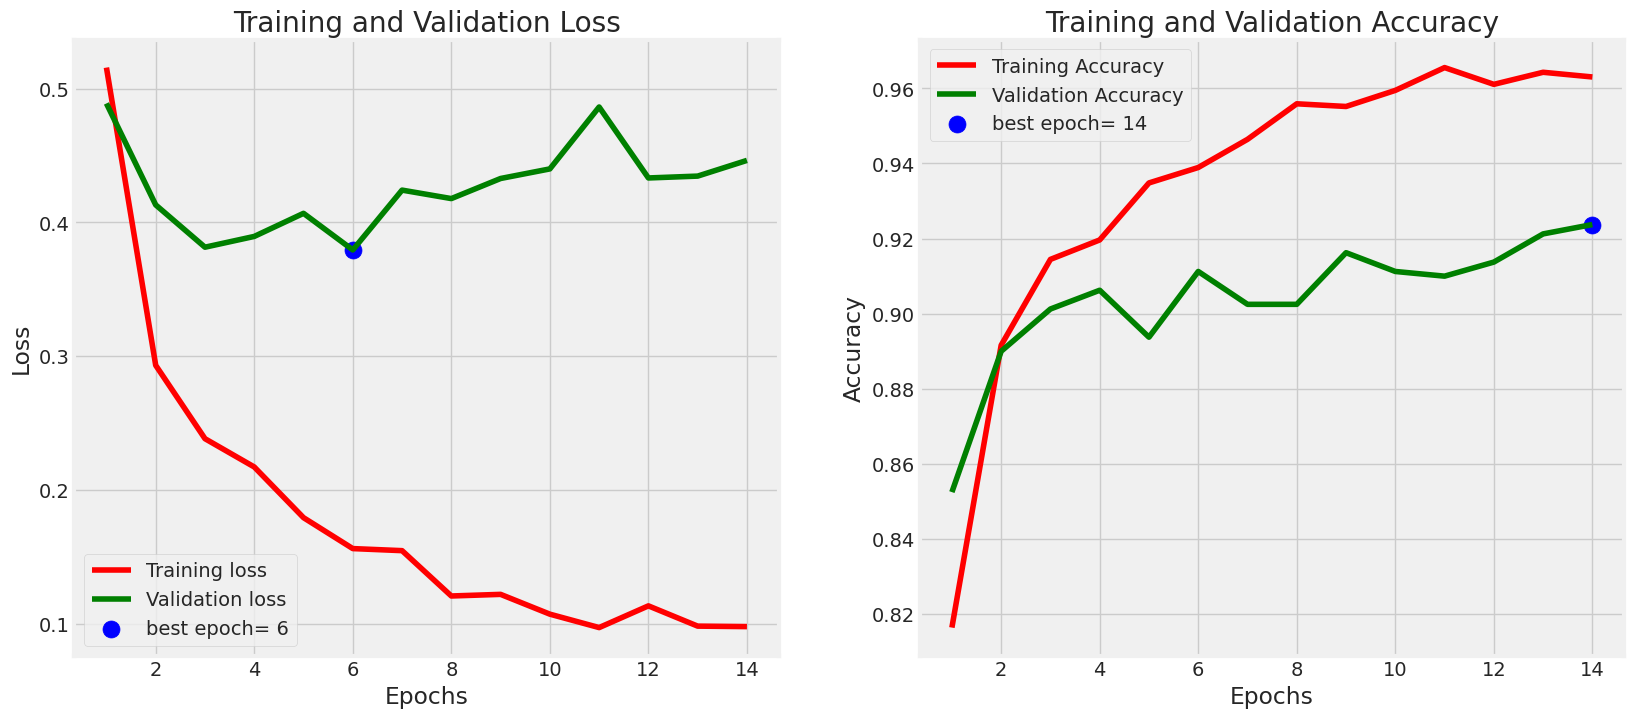

In [10]:
# Define needed variables
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]

Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

In [11]:
_, test_acc = model.evaluate(test_generator, verbose=1)
print(f"Test Accuracy: {test_acc*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 302ms/step - accuracy: 0.9282 - loss: 0.3411
Test Accuracy: 92.37%


27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 272ms/step


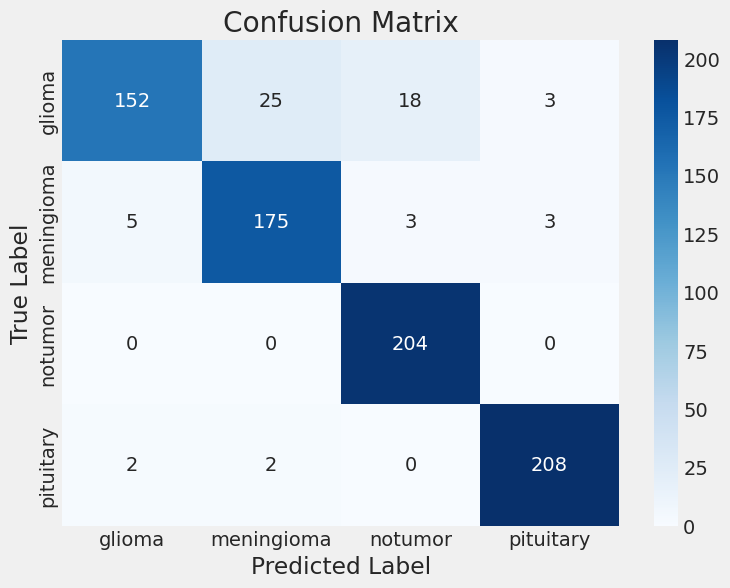

              precision    recall  f1-score   support

      glioma       0.96      0.77      0.85       198
  meningioma       0.87      0.94      0.90       186
     notumor       0.91      1.00      0.95       204
   pituitary       0.97      0.98      0.98       212

    accuracy                           0.92       800
   macro avg       0.93      0.92      0.92       800
weighted avg       0.93      0.92      0.92       800



In [12]:
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes


class_names = list(test_generator.class_indices.keys())


cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification report
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# 💾 Save Model

In [13]:
model.save('brain tumor_efficientnet_model.keras')
print("Saved model")

Saved model
